# Critical eigenvector vs final nonlinear pattern validation

Goal: validate whether the critical Laplacian eigenvector predicted by linear stability resembles the final nonlinear spatial pattern after integrating the full crime–opportunity system.

Conventions preserved from ring.ipynb:
- Laplacian convention: L = A − D (non-positive eigenvalues; homogeneous mode at λ = 0).
- Exclude λ = 0 from critical-mode selection.
- Keep params["do"] naming (do not rename).
- Keep the function name dispertion_relation for compatibility (spelling preserved).

Key idea: changing shortcut probability p changes the graph spectrum, so do must be updated consistently from the *current* spectrum using the analytical modal-selection formula (no grid search, no scaling factors, no optimization):

do(λ_target) = (α + β) / (2 λ_target²).

In [51]:
# Imports
import numpy as np
import scipy as sp
from scipy.integrate import solve_ivp
from scipy.stats import spearmanr
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=6, suppress=True)

## Base parameters

We define a base params dictionary and then copy/update it per graph. After do is changed we recompute Ic, I, rho_ss, O_ss, lambda_c consistently (keeping the original logic I = Ic + epsilon_I).

In [52]:
# Base parameters (reuse ring.ipynb conventions)
alpha = 0.0050415
beta = 0.000013047
delta = 0.0079639

# Placeholder do (will be overwritten analytically per-graph)
do = 0.0017783

rho_ss = alpha * delta / (alpha + beta)
O_ss = (alpha + beta) / delta

params = {
    'alpha': alpha,
    'beta': beta,
    'delta': delta,
    'do': do,
    'rho_ss': rho_ss,
    'O_ss': O_ss,
    'I': np.nan,
    'lambda_c': np.nan,
}
params

{'alpha': 0.0050415,
 'beta': 1.3047e-05,
 'delta': 0.0079639,
 'do': 0.0017783,
 'rho_ss': 0.007943343261028139,
 'O_ss': 0.6346823792363039,
 'I': nan,
 'lambda_c': nan}

## PHASE 1 — Parameter utilities

In [53]:
def copy_params(params):
    """
    Return a shallow copy of the parameter dictionary to avoid modifying
    the global params accidentally.
    """
    return dict(params)


def compute_Ic(params):
    """
    Compute the critical value Ic using the same formula as in ring.ipynb.
    """
    alpha = params['alpha']
    beta = params['beta']
    delta = params['delta']
    do = params['do']

    numerator = (
        2 * delta**2 * beta
        + do * (alpha + beta)**2
        + 2 * (alpha + beta) * delta * np.sqrt(2 * do * (alpha + beta))
    )
    denominator = 2 * alpha * delta**2
    return numerator / denominator


def update_dynamic_parameters_from_do(params, epsilon_I=0.01):
    """
    After params['do'] is changed, recompute Ic, I, rho_ss, O_ss, and lambda_c
    consistently. Keep the model slightly above threshold: I = Ic + epsilon_I.
    """
    params_new = copy_params(params)

    alpha = params_new['alpha']
    beta = params_new['beta']
    delta = params_new['delta']
    do = params_new['do']

    Ic = compute_Ic(params_new)
    I = Ic + epsilon_I

    params_new['Ic'] = float(Ic)
    params_new['I'] = float(I)

    rho_ss = alpha * delta / (alpha + beta)
    O_ss = (alpha + beta) / delta
    params_new['rho_ss'] = float(rho_ss)
    params_new['O_ss'] = float(O_ss)

    lambda_c = (
        do * (alpha + beta)**2
        + 2 * beta * delta**2
        - 2 * I * alpha * delta**2
    ) / (4 * do * delta * (alpha + beta))
    params_new['lambda_c'] = float(lambda_c)

    return params_new

## PHASE 2 — Spectrum and IPR utilities

In [54]:
def compute_laplacian_spectrum(graph):
    """
    Compute A, L, eigenvalues, and eigenvectors using the convention L = A - D.
    """
    A = nx.to_numpy_array(graph, dtype=float)
    L = A - np.diag(A.sum(axis=1))
    # numerical symmetry guard
    L = (L + L.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    return A, L, eigenvalues, eigenvectors


def compute_ipr(eigenvectors):
    """
    Compute inverse participation ratio for every eigenvector column.
    IPR(phi) = sum_i phi_i^4 / (sum_i phi_i^2)^2
    """
    phi2 = np.sum(eigenvectors**2, axis=0)
    phi4 = np.sum(eigenvectors**4, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ipr = phi4 / (phi2**2)
    return ipr


def get_nonzero_modes(eigenvalues, eigenvectors, tol=1e-10):
    """
    Exclude the homogeneous eigenvalue lambda = 0.
    Return nonzero eigenvalues, nonzero eigenvectors, and original indices.
    """
    nonzero_mask = ~np.isclose(eigenvalues, 0.0, atol=tol)
    indices = np.where(nonzero_mask)[0]
    return eigenvalues[nonzero_mask], eigenvectors[:, nonzero_mask], indices

## PHASE 3 — Target eigenvalue selection

In [55]:
def select_target_eigenvalue(
    eigenvalues,
    eigenvectors,
    target_rule='random',
    q=0.5,
    reference_lambda=None,
    rng=None,
):
    """
    Select the target nonzero eigenvalue used to compute params['do'] analytically.

    Available rules:
    - 'random': select a uniformly random nonzero mode (optionally pass rng for reproducibility).
    - 'max_ipr': select nonzero mode with largest IPR (most localized).
    - 'middle_spectrum': select middle nonzero eigenvalue.
    - 'fixed_quantile': select nonzero eigenvalue closest to quantile q.
    - 'closest_to_reference': select nonzero eigenvalue closest to reference_lambda.
    """
    eigenvalues = np.asarray(eigenvalues, dtype=float)

    if len(eigenvalues) == 0:
        raise ValueError('No nonzero eigenvalues available for target selection.')

    if target_rule == 'random':
        if rng is None:
            rng = np.random.default_rng()
        j = int(rng.integers(0, len(eigenvalues)))
    else:
        ipr = compute_ipr(eigenvectors)

        if target_rule == 'max_ipr':
            j = int(np.nanargmax(ipr))
        elif target_rule == 'middle_spectrum':
            j = int(len(eigenvalues) // 2)
        elif target_rule == 'fixed_quantile':
            target_val = float(np.quantile(eigenvalues, q))
            j = int(np.argmin(np.abs(eigenvalues - target_val)))
        elif target_rule == 'closest_to_reference':
            if reference_lambda is None:
                raise ValueError('reference_lambda must be provided for closest_to_reference.')
            j = int(np.argmin(np.abs(eigenvalues - reference_lambda)))
        else:
            raise ValueError(f'Unknown target_rule: {target_rule}')

    # Always compute IPR for the chosen mode for reporting
    ipr_all = compute_ipr(eigenvectors)
    lambda_target = float(eigenvalues[j])
    ipr_target = float(ipr_all[j]) if np.isfinite(ipr_all[j]) else np.nan
    return lambda_target, j, ipr_target

## PHASE 4 — Analytical do selection

In [56]:
def set_do_from_target_lambda(params, lambda_target, epsilon_I=0.01):
    """
    Set params['do'] directly from the analytical modal-selection formula:
        do = (alpha + beta) / (2 * lambda_target**2)
    Then recompute Ic, I, rho_ss, O_ss, and lambda_c consistently.
    """
    if np.isclose(lambda_target, 0.0):
        raise ValueError('lambda_target must be nonzero.')

    params_new = copy_params(params)
    alpha = params_new['alpha']
    beta = params_new['beta']

    params_new['do'] = float((alpha + beta) / (2.0 * (lambda_target**2)))
    params_new = update_dynamic_parameters_from_do(params_new, epsilon_I=epsilon_I)
    return params_new

## PHASE 5 — Dispersion relation (matrix form)

We compute η(λ) as the maximum real part of the eigenvalues of the 2×2 linearized matrix M(λ). This avoids fragile closed-form discriminants and is easy to evaluate on a discrete spectrum.

In [57]:
def eta_from_matrix(lambda_value, params):
    """
    Compute eta(lambda) as max real part of eigenvalues of the 2x2 matrix M(lambda).
    """
    alpha = params['alpha']
    beta = params['beta']
    delta = params['delta']
    do = params['do']
    I = params['I']

    lam = float(lambda_value)

    M = np.array(
        [
            [2 * lam - (alpha + beta) / delta,
             - (2 * I * alpha * delta**2 / (alpha + beta)**2) * lam - (alpha * delta) / (alpha + beta)],
            [(alpha + beta) / delta,
             do * lam - (beta * delta) / (alpha + beta)],
        ],
        dtype=float,
    )
    eigs = np.linalg.eigvals(M)
    return float(np.max(np.real(eigs)))


def eta_on_spectrum(eigenvalues, params, exclude_zero=True, tol=1e-10):
    """
    Evaluate eta(lambda_alpha) on the Laplacian spectrum.
    Return selected eigenvalues, eta values, and original indices.
    """
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    if exclude_zero:
        mask = ~np.isclose(eigenvalues, 0.0, atol=tol)
    else:
        mask = np.ones_like(eigenvalues, dtype=bool)
    indices = np.where(mask)[0]
    selected = eigenvalues[mask]
    eta_vals = np.array([eta_from_matrix(lam, params) for lam in selected], dtype=float)
    return selected, eta_vals, indices


def dispertion_relation(params, plot=False, eigenvalues=None, index_critical_eigenvalue=None):
    """
    Compatibility wrapper (spelling preserved).
    Returns a dict with min_lambda, max_lambda, and a callable function eta(lambda).
    """
    # Range similar to ring.ipynb; can be overridden by eigenvalues if provided
    if eigenvalues is not None:
        lam_min = float(np.min(eigenvalues))
        lam_left = min(-8.0, 1.1 * lam_min)
    else:
        lam_left = -8.0
    lambda_vals = np.linspace(lam_left, 0.0, 500)

    def eta_vec(lams):
        lams = np.asarray(lams, dtype=float)
        return np.array([eta_from_matrix(l, params) for l in lams], dtype=float)

    eta_vals = eta_vec(lambda_vals)
    positive = np.where(eta_vals > 0)[0]
    if len(positive) > 0:
        min_lambda = float(lambda_vals[positive[0]])
        max_lambda = float(lambda_vals[positive[-1]])
    else:
        min_lambda = np.nan
        max_lambda = np.nan

    if plot:
        plt.figure(figsize=(7, 4))
        plt.plot(lambda_vals, eta_vals, label='eta(lambda)')
        plt.axhline(0, color='black', linewidth=1)
        plt.fill_between(lambda_vals, 0, eta_vals, where=eta_vals > 0, alpha=0.2)
        if eigenvalues is not None:
            eig_eta = np.array([eta_from_matrix(l, params) for l in eigenvalues], dtype=float)
            plt.scatter(eigenvalues, eig_eta, s=20, c='red', label='Spectrum')
            if index_critical_eigenvalue is not None:
                plt.scatter([eigenvalues[index_critical_eigenvalue]], [eig_eta[index_critical_eigenvalue]],
                            s=70, c='green', label='Highlighted')
        plt.xlabel('lambda')
        plt.ylabel('eta(lambda)')
        plt.title('Dispersion relation (matrix form)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {'min_lambda': min_lambda, 'max_lambda': max_lambda, 'function': eta_vec}

## PHASE 6 — Linear prediction

Important: λ_target is used only to set do analytically. The actual λ_critical is the eigenvalue that maximizes η(λ) after do is updated.

In [58]:
def get_linear_prediction(
    graph,
    params,
    target_rule='random',
    q=0.5,
    reference_lambda=None,
    epsilon_I=0.01,
    rng=None,
):
    """
    Compute critical eigenvector predicted by linear stability analysis,
    with do set analytically from a selected target eigenvalue.

    Note: lambda_target is only used to set do analytically. The actual lambda_critical
    is the eigenvalue that maximizes eta(lambda) after do is updated.

    If target_rule='random', pass rng for reproducible selection.
    """
    A, L, eigenvalues, eigenvectors = compute_laplacian_spectrum(graph)
    IPR_all = compute_ipr(eigenvectors)

    nonzero_eigs, nonzero_vecs, nonzero_indices = get_nonzero_modes(eigenvalues, eigenvectors)

    # Select lambda_target on the nonzero spectrum
    lambda_target, local_target_index, ipr_target = select_target_eigenvalue(
        nonzero_eigs,
        nonzero_vecs,
        target_rule=target_rule,
        q=q,
        reference_lambda=reference_lambda,
        rng=rng,
    )
    target_index = int(nonzero_indices[local_target_index])

    # Set do analytically, then recompute Ic, I, rho_ss, O_ss, lambda_c
    params_selected = set_do_from_target_lambda(params, lambda_target, epsilon_I=epsilon_I)

    selected_nonzero_eigenvalues, eta_values, selected_indices_local = eta_on_spectrum(
        eigenvalues, params_selected, exclude_zero=True
    )
    selected_indices = nonzero_indices  # original indices for selected_nonzero_eigenvalues

    # Critical mode: argmax eta over nonzero spectrum
    critical_local = int(np.argmax(eta_values))
    critical_index = int(selected_indices[critical_local])
    critical_eigenvalue = float(eigenvalues[critical_index])

    phi_critical = np.asarray(eigenvectors[:, critical_index], dtype=float)
    norm_phi = np.linalg.norm(phi_critical)
    if norm_phi > 0:
        phi_critical = phi_critical / norm_phi

    ipr_critical = float(np.sum(phi_critical**4) / (np.sum(phi_critical**2)**2))

    eta_max = float(np.max(eta_values))
    if len(eta_values) >= 2:
        eta_sorted = np.sort(eta_values)
        eta_gap = float(eta_sorted[-1] - eta_sorted[-2])
    else:
        eta_gap = np.nan

    number_unstable_modes = int(np.sum(eta_values > 0))
    stable_flag = bool(eta_max <= 0)

    return {
        'A': A,
        'L': L,
        'eigenvalues': eigenvalues,
        'eigenvectors': eigenvectors,
        'IPR_all_eigenvectors': IPR_all,
        'lambda_target': lambda_target,
        'target_index': target_index,
        'ipr_target': ipr_target,
        'params_selected': params_selected,
        'do_selected': float(params_selected['do']),
        'Ic_selected': float(params_selected['Ic']),
        'I_selected': float(params_selected['I']),
        'rho_ss_selected': float(params_selected['rho_ss']),
        'O_ss_selected': float(params_selected['O_ss']),
        'lambda_c_selected': float(params_selected['lambda_c']),
        'eta_values': eta_values,
        'selected_nonzero_eigenvalues': selected_nonzero_eigenvalues,
        'selected_indices': selected_indices,
        'critical_index': critical_index,
        'critical_eigenvalue': critical_eigenvalue,
        'critical_eigenvector': phi_critical,
        'ipr_critical': ipr_critical,
        'eta_max': eta_max,
        'eta_gap': eta_gap,
        'number_unstable_modes': number_unstable_modes,
        'stable_flag': stable_flag,
    }

## PHASE 7 — Nonlinear integration

We integrate the full nonlinear crime–opportunity system using the same equations as ring.ipynb. Final patterns of interest: rho_final = rho(t_final), O_final = O(t_final). For signed comparisons we use centered versions rho_final − rho_ss and O_final − O_ss.

In [59]:
def integrate_nonlinear_pattern(
    graph,
    params,
    epsilon=1e-3,
    t_final=1_000_000,
    n_time_points=1000,
    seed=0,
    method='BDF',
):
    """
    Integrate the full nonlinear system and return the final nonlinear pattern.

    Returns: solution, rho_final, O_final, rho_centered_final, O_centered_final, integration_success
    """
    alpha = params['alpha']
    beta = params['beta']
    delta = params['delta']
    do = params['do']
    I = params['I']
    rho_ss = params['rho_ss']
    O_ss = params['O_ss']

    A = nx.to_numpy_array(graph, dtype=float)
    n = A.shape[0]

    # Precompute neighbor lists and weights
    neighbors = []
    weights = []
    for i in range(n):
        nbr = np.flatnonzero(A[i] != 0)
        neighbors.append(nbr)
        weights.append(A[i, nbr])

    rng = np.random.default_rng(seed)
    noise = rng.uniform(-1.0, 1.0, size=n)
    rho0 = rho_ss * (1.0 + epsilon * noise)
    O0 = O_ss * (1.0 + epsilon * noise)
    O0 = np.clip(O0, 1e-12, None)

    y0 = np.column_stack([rho0, O0]).reshape(-1)
    t_span = (0.0, float(t_final))
    t_eval = np.linspace(t_span[0], t_span[1], int(n_time_points))

    def rhs(t, y_flat):
        y = y_flat.reshape(n, 2)
        rho = y[:, 0]
        O = y[:, 1]
        O_safe = np.clip(O, 1e-12, None)

        drho = np.zeros(n, dtype=float)
        dO = np.zeros(n, dtype=float)

        for i in range(n):
            nbr = neighbors[i]
            w = weights[i]
            if nbr.size == 0:
                diff_rho = 0.0
                diff_O = 0.0
                nonlinear = 0.0
            else:
                rho_j = rho[nbr]
                O_j = O_safe[nbr]
                O_i = O_safe[i]

                diff_rho = np.sum(w * (rho_j - rho[i]))
                diff_O = np.sum(w * (O_j - O_i))

                ratio_i_j = (O_i / O_j) ** I
                ratio_j_i = (O_j / O_i) ** I
                nonlinear = np.sum(w * (ratio_i_j * rho_j - ratio_j_i * rho[i]))

            drho[i] = -rho[i] * O_safe[i] + alpha + diff_rho + nonlinear
            dO[i] = -delta * O_safe[i] + beta + rho[i] * O_safe[i] + do * diff_O

        return np.column_stack([drho, dO]).reshape(-1)

    try:
        sol = solve_ivp(rhs, t_span, y0, method=method, t_eval=t_eval)
    except Exception as exc:
        sol = None
        rho_final = np.full(n, np.nan)
        O_final = np.full(n, np.nan)
        return sol, rho_final, O_final, rho_final - rho_ss, O_final - O_ss, False

    if (sol is None) or (not sol.success) or (sol.y.size == 0):
        rho_final = np.full(n, np.nan)
        O_final = np.full(n, np.nan)
        return sol, rho_final, O_final, rho_final - rho_ss, O_final - O_ss, False

    yT = sol.y[:, -1].reshape(n, 2)
    rho_final = yT[:, 0]
    O_final = yT[:, 1]

    rho_centered = rho_final - rho_ss
    O_centered = O_final - O_ss
    return sol, rho_final, O_final, rho_centered, O_centered, True

## PHASE 8 — Pattern comparison

We compare the critical eigenvector φ (baseline 0) against the final nonlinear patterns centered around their homogeneous baselines: z_rho = rho_final − rho_ss and z_O = O_final − O_ss. Signed metrics align φ's sign first; unsigned metrics compare magnitudes.

In [60]:
def _safe_pearson(x, y, tol=1e-14):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size != y.size:
        return np.nan
    if (np.std(x) < tol) or (np.std(y) < tol):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _cosine_similarity(x, y, tol=1e-14):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx_ = np.linalg.norm(x)
    ny_ = np.linalg.norm(y)
    if (nx_ < tol) or (ny_ < tol):
        return np.nan
    return float(np.dot(x, y) / (nx_ * ny_))


def compare_eigenvector_to_final_pattern(phi, rho_final, O_final, params, k=5, tol=1e-10):
    """
    Compare critical eigenvector phi against final nonlinear patterns.
    Signed comparisons use centered patterns relative to homogeneous baseline:
        z_rho = rho_final - rho_ss
        z_O   = O_final   - O_ss
    Eigenvector sign is aligned separately for rho and O.
    """
    phi = np.asarray(phi, dtype=float)
    rho_final = np.asarray(rho_final, dtype=float)
    O_final = np.asarray(O_final, dtype=float)

    rho_ss = float(params['rho_ss'])
    O_ss = float(params['O_ss'])

    z_rho = rho_final - rho_ss
    z_O = O_final - O_ss

    # Normalize for cosine and stable numerics (Pearson doesn't need this, but it doesn't hurt)
    phi_n = phi / (np.linalg.norm(phi) + 1e-300)

    corr_rho = _safe_pearson(phi_n, z_rho)
    corr_O = _safe_pearson(phi_n, z_O)

    phi_rho = phi_n if (np.nan_to_num(corr_rho) >= 0) else -phi_n
    phi_O = phi_n if (np.nan_to_num(corr_O) >= 0) else -phi_n

    # Signed metrics
    corr_signed_rho = _safe_pearson(phi_rho, z_rho)
    corr_signed_O = _safe_pearson(phi_O, z_O)

    cosine_signed_rho = _cosine_similarity(phi_rho, z_rho)
    cosine_signed_O = _cosine_similarity(phi_O, z_O)

    def sign_agreement(a, b):
        mask = (np.abs(a) > tol) & (np.abs(b) > tol)
        if np.sum(mask) == 0:
            return np.nan
        return float(np.mean(np.sign(a[mask]) == np.sign(b[mask])))

    sign_agreement_rho = sign_agreement(phi_rho, z_rho)
    sign_agreement_O = sign_agreement(phi_O, z_O)

    def jaccard_regions(a, b, region='above'):
        if region == 'above':
            A = a > tol
            B = b > tol
        else:
            A = a < -tol
            B = b < -tol
        union = np.sum(A | B)
        if union == 0:
            return np.nan
        inter = np.sum(A & B)
        return float(inter / union)

    jaccard_above_rho = jaccard_regions(phi_rho, z_rho, region='above')
    jaccard_above_O = jaccard_regions(phi_O, z_O, region='above')
    jaccard_below_rho = jaccard_regions(phi_rho, z_rho, region='below')
    jaccard_below_O = jaccard_regions(phi_O, z_O, region='below')

    # Unsigned magnitude metrics
    abs_phi = np.abs(phi_n)
    abs_z_rho = np.abs(z_rho)
    abs_z_O = np.abs(z_O)

    corr_abs_rho = _safe_pearson(abs_phi, abs_z_rho)
    corr_abs_O = _safe_pearson(abs_phi, abs_z_O)

    try:
        spearman_abs_rho = float(spearmanr(abs_phi, abs_z_rho, nan_policy='omit').correlation)
    except Exception:
        spearman_abs_rho = np.nan
    try:
        spearman_abs_O = float(spearmanr(abs_phi, abs_z_O, nan_policy='omit').correlation)
    except Exception:
        spearman_abs_O = np.nan

    def topk_overlap(a, b, k):
        n = a.size
        k_eff = int(min(k, n))
        idx_a = np.argsort(a)[-k_eff:]
        idx_b = np.argsort(b)[-k_eff:]
        return float(len(set(idx_a).intersection(set(idx_b))) / k_eff)

    topk_overlap_abs_rho = topk_overlap(abs_phi, abs_z_rho, k)
    topk_overlap_abs_O = topk_overlap(abs_phi, abs_z_O, k)

    # Secondary squared metrics
    corr_squared_rho = _safe_pearson(phi_n**2, z_rho**2)
    corr_squared_O = _safe_pearson(phi_n**2, z_O**2)

    return {
        'z_rho': z_rho,
        'z_O': z_O,
        'phi_rho_aligned': phi_rho,
        'phi_O_aligned': phi_O,
        'corr_signed_rho': corr_signed_rho,
        'corr_signed_O': corr_signed_O,
        'cosine_signed_rho': cosine_signed_rho,
        'cosine_signed_O': cosine_signed_O,
        'sign_agreement_rho': sign_agreement_rho,
        'sign_agreement_O': sign_agreement_O,
        'jaccard_above_rho': jaccard_above_rho,
        'jaccard_above_O': jaccard_above_O,
        'jaccard_below_rho': jaccard_below_rho,
        'jaccard_below_O': jaccard_below_O,
        'corr_abs_rho': corr_abs_rho,
        'corr_abs_O': corr_abs_O,
        'spearman_abs_rho': spearman_abs_rho,
        'spearman_abs_O': spearman_abs_O,
        'topk_overlap_abs_rho': topk_overlap_abs_rho,
        'topk_overlap_abs_O': topk_overlap_abs_O,
        'corr_squared_rho': corr_squared_rho,
        'corr_squared_O': corr_squared_O,
    }

## PHASE 9 — Single validation experiment

In [61]:
def run_single_validation_experiment(
    p,
    seed,
    n_nodes,
    n_neighbors,
    params,
    target_rule='random',
    q=0.5,
    reference_lambda=None,
    epsilon_I=0.01,
    force_integration=False,
):
    """
    One complete validation experiment:
        graph -> analytical do -> linear prediction -> nonlinear integration -> comparison.

    If target_rule='random', we seed the RNG with `seed` so runs are reproducible.
    """
    graph = nx.newman_watts_strogatz_graph(n=n_nodes, k=n_neighbors, p=p, seed=seed)
    if not nx.is_connected(graph):
        # For Newman-Watts with k>=2 this should be connected, but keep a safeguard.
        for s2 in range(seed + 1, seed + 50):
            graph = nx.newman_watts_strogatz_graph(n=n_nodes, k=n_neighbors, p=p, seed=s2)
            if nx.is_connected(graph):
                seed = s2
                break

    rng_target = np.random.default_rng(seed) if target_rule == 'random' else None

    lin = get_linear_prediction(
        graph,
        params,
        target_rule=target_rule,
        q=q,
        reference_lambda=reference_lambda,
        epsilon_I=epsilon_I,
        rng=rng_target,
    )

    stable_flag = lin['stable_flag']
    integration_success = np.nan

    # Defaults (NaN unless integrated)
    metrics = {
        'corr_signed_rho': np.nan, 'corr_signed_O': np.nan,
        'cosine_signed_rho': np.nan, 'cosine_signed_O': np.nan,
        'sign_agreement_rho': np.nan, 'sign_agreement_O': np.nan,
        'jaccard_above_rho': np.nan, 'jaccard_above_O': np.nan,
        'jaccard_below_rho': np.nan, 'jaccard_below_O': np.nan,
        'corr_abs_rho': np.nan, 'corr_abs_O': np.nan,
        'spearman_abs_rho': np.nan, 'spearman_abs_O': np.nan,
        'topk_overlap_abs_rho': np.nan, 'topk_overlap_abs_O': np.nan,
        'corr_squared_rho': np.nan, 'corr_squared_O': np.nan,
    }

    rho_final = np.full(n_nodes, np.nan)
    O_final = np.full(n_nodes, np.nan)

    if (not stable_flag) or force_integration:
        sol, rho_final, O_final, z_rho, z_O, integration_success = integrate_nonlinear_pattern(
            graph, lin['params_selected'], seed=seed
        )
        if integration_success:
            metrics = compare_eigenvector_to_final_pattern(
                lin['critical_eigenvector'], rho_final, O_final, lin['params_selected'], k=5
            )

    # Summary stats for raw final patterns (required summaries)
    def summarize(x):
        x = np.asarray(x, dtype=float)
        return {
            'mean': float(np.nanmean(x)),
            'std': float(np.nanstd(x)),
            'min': float(np.nanmin(x)),
            'max': float(np.nanmax(x)),
        }

    rho_stats = summarize(rho_final)
    O_stats = summarize(O_final)

    return {
        'topology': 'newman_watts_ring',
        'p': float(p),
        'seed': int(seed),
        'n_nodes': int(n_nodes),
        'n_neighbors': int(n_neighbors),
        'target_rule': str(target_rule),
        'lambda_target': float(lin['lambda_target']),
        'target_index': int(lin['target_index']),
        'ipr_target': float(lin['ipr_target']),
        'do_selected': float(lin['do_selected']),
        'Ic_selected': float(lin['Ic_selected']),
        'I_selected': float(lin['I_selected']),
        'rho_ss_selected': float(lin['rho_ss_selected']),
        'O_ss_selected': float(lin['O_ss_selected']),
        'lambda_c_selected': float(lin['lambda_c_selected']),
        'lambda_critical': float(lin['critical_eigenvalue']),
        'eta_max': float(lin['eta_max']),
        'eta_gap': float(lin['eta_gap']) if np.isfinite(lin['eta_gap']) else np.nan,
        'number_unstable_modes': int(lin['number_unstable_modes']),
        'critical_index': int(lin['critical_index']),
        'ipr_critical': float(lin['ipr_critical']),
        'stable_flag': bool(stable_flag),
        'integration_success': integration_success,
        'rho_final_mean': rho_stats['mean'],
        'rho_final_std': rho_stats['std'],
        'rho_final_min': rho_stats['min'],
        'rho_final_max': rho_stats['max'],
        'O_final_mean': O_stats['mean'],
        'O_final_std': O_stats['std'],
        'O_final_min': O_stats['min'],
        'O_final_max': O_stats['max'],
        'corr_signed_rho': float(metrics['corr_signed_rho']),
        'corr_signed_O': float(metrics['corr_signed_O']),
        'cosine_signed_rho': float(metrics['cosine_signed_rho']),
        'cosine_signed_O': float(metrics['cosine_signed_O']),
        'sign_agreement_rho': float(metrics['sign_agreement_rho']),
        'sign_agreement_O': float(metrics['sign_agreement_O']),
        'jaccard_above_rho': float(metrics['jaccard_above_rho']),
        'jaccard_above_O': float(metrics['jaccard_above_O']),
        'jaccard_below_rho': float(metrics['jaccard_below_rho']),
        'jaccard_below_O': float(metrics['jaccard_below_O']),
        'corr_abs_rho': float(metrics['corr_abs_rho']),
        'corr_abs_O': float(metrics['corr_abs_O']),
        'spearman_abs_rho': float(metrics['spearman_abs_rho']),
        'spearman_abs_O': float(metrics['spearman_abs_O']),
        'top5_overlap_abs_rho': float(metrics['topk_overlap_abs_rho']),
        'top5_overlap_abs_O': float(metrics['topk_overlap_abs_O']),
        'corr_squared_rho': float(metrics['corr_squared_rho']),
        'corr_squared_O': float(metrics['corr_squared_O']),
    }

## PHASE 10 — Ensemble execution

We run sequentially by default (no multiprocessing) to keep debugging simple. Start with RUN_FULL_ENSEMBLE=False.

In [191]:
def run_validation_ensemble(
    p_values,
    seeds,
    n_nodes,
    n_neighbors,
    params,
    target_rule='random',
    q=0.5,
    reference_lambda=None,
    epsilon_I=0.01,
):
    results = []
    for p in p_values:
        for seed in seeds:
            print(f'Running p={p}, seed={seed}...')
            res = run_single_validation_experiment(
                p=p,
                seed=seed,
                n_nodes=n_nodes,
                n_neighbors=n_neighbors,
                params=params,
                target_rule=target_rule,
                q=q,
                reference_lambda=reference_lambda,
                epsilon_I=epsilon_I,
            )
            results.append(res)
    return pd.DataFrame(results)


RUN_FULL_ENSEMBLE = True

n_nodes = 20
n_neighbors = 4

if RUN_FULL_ENSEMBLE is False:
    p_values = [0.0, 0.1, 1.0]
    seeds = [0, 1]

if RUN_FULL_ENSEMBLE is True:
    # Smooth sweep of p across [0, 1]
    n_p = 51  # increase for finer resolution (e.g., 51 or 101)
    p_values = np.linspace(0.0, 1.0, n_p)
    seeds = range(5)


In [192]:
validation_df = run_validation_ensemble(
    p_values=p_values,
    seeds=seeds,
    n_nodes=n_nodes,
    n_neighbors=n_neighbors,
    params=params,
    target_rule='random',
    q=0.5,
    reference_lambda=None,
    epsilon_I=0.01,
)

validation_df.head()

Running p=0.0, seed=0...
Running p=0.0, seed=1...
Running p=0.0, seed=2...
Running p=0.0, seed=3...
Running p=0.0, seed=4...
Running p=0.02, seed=0...
Running p=0.02, seed=1...
Running p=0.02, seed=2...
Running p=0.02, seed=3...
Running p=0.02, seed=4...
Running p=0.04, seed=0...
Running p=0.04, seed=1...
Running p=0.04, seed=2...
Running p=0.04, seed=3...
Running p=0.04, seed=4...
Running p=0.06, seed=0...
Running p=0.06, seed=1...
Running p=0.06, seed=2...
Running p=0.06, seed=3...
Running p=0.06, seed=4...
Running p=0.08, seed=0...
Running p=0.08, seed=1...
Running p=0.08, seed=2...
Running p=0.08, seed=3...
Running p=0.08, seed=4...
Running p=0.1, seed=0...
Running p=0.1, seed=1...
Running p=0.1, seed=2...
Running p=0.1, seed=3...
Running p=0.1, seed=4...
Running p=0.12, seed=0...
Running p=0.12, seed=1...
Running p=0.12, seed=2...
Running p=0.12, seed=3...
Running p=0.12, seed=4...
Running p=0.14, seed=0...
Running p=0.14, seed=1...
Running p=0.14, seed=2...
Running p=0.14, seed=3

,topology,p,seed,n_nodes,n_neighbors,target_rule,lambda_target,target_index,ipr_target,do_selected,...,jaccard_below_rho,jaccard_below_O,corr_abs_rho,corr_abs_O,spearman_abs_rho,spearman_abs_O,top5_overlap_abs_rho,top5_overlap_abs_O,corr_squared_rho,corr_squared_O
0,newman_watts_ring,0.0,0,20,4,random,-1.763932,16,0.075000,0.000812,...,1.000000,1.000000,0.616011,0.748185,0.786010,0.770967,0.6,0.8,0.591753,0.796168
1,newman_watts_ring,0.0,1,20,4,random,-5.000000,8,0.149097,0.000101,...,0.500000,0.500000,-0.983192,0.983190,-0.715789,0.718797,0.0,0.4,-0.973465,0.973462
2,newman_watts_ring,0.0,2,20,4,random,-1.763932,15,0.075000,0.000812,...,0.250000,0.250000,-0.691632,-0.809445,-0.802557,-0.954494,0.0,0.0,-0.682398,-0.918123
3,newman_watts_ring,0.0,3,20,4,random,-1.763932,15,0.075000,0.000812,...,0.285714,0.428571,-0.689008,-0.689113,-0.776984,-0.773975,0.0,0.0,NaN,-0.755167
4,newman_watts_ring,0.0,4,20,4,random,-3.442463,13,0.075000,0.000213,...,0.833333,0.909091,-0.023467,0.050422,0.090226,0.042105,0.2,0.2,0.074593,0.035172


In [193]:
# Save results
out_csv = f'critical_eigenvector_final_pattern_validation_results_20_nodes_p_{n_p}.csv'
validation_df.to_csv(out_csv, index=False)
out_csv

'critical_eigenvector_final_pattern_validation_results_20_nodes_p_51.csv'

## PHASE 11 — Plots

We produce representative plots for one selected (preferably unstable + successfully integrated) experiment, plus ensemble-level summaries.

In [194]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   topology               255 non-null    object 
 1   p                      255 non-null    float64
 2   seed                   255 non-null    int64  
 3   n_nodes                255 non-null    int64  
 4   n_neighbors            255 non-null    int64  
 5   target_rule            255 non-null    object 
 6   lambda_target          255 non-null    float64
 7   target_index           255 non-null    int64  
 8   ipr_target             255 non-null    float64
 9   do_selected            255 non-null    float64
 10  Ic_selected            255 non-null    float64
 11  I_selected             255 non-null    float64
 12  rho_ss_selected        255 non-null    float64
 13  O_ss_selected          255 non-null    float64
 14  lambda_c_selected      255 non-null    float64
 15  lambda

In [195]:
# Select a representative random experiment
rep_row =  None
if 'integration_success' in validation_df.columns:
    # random row selection
    ok = validation_df[(validation_df['stable_flag'] == False) & (validation_df['integration_success'] == True)]
    if len(ok) > 0:
        rep_row = ok.sample(n=1).iloc[0]

if rep_row is None:
    # fallback: first row (may be stable or not integrated)
    rep_row = validation_df.iloc[0]

rep_p = float(rep_row['p'])
rep_seed = int(rep_row['seed'])
rep_p, rep_seed

(0.42, 2)

In [196]:
# Re-run the representative case to get full objects (eigenvectors + raw final patterns)
G_rep = nx.newman_watts_strogatz_graph(n=n_nodes, k=n_neighbors, p=rep_p, seed=rep_seed)

rng_rep = np.random.default_rng(rep_seed)
lin_rep = get_linear_prediction(G_rep, params, target_rule='random', epsilon_I=0.01, rng=rng_rep)

sol_rep, rho_final_rep, O_final_rep, z_rho_rep, z_O_rep, success_rep = integrate_nonlinear_pattern(
    G_rep, lin_rep['params_selected'], seed=rep_seed
)

comp_rep = compare_eigenvector_to_final_pattern(
    lin_rep['critical_eigenvector'], rho_final_rep, O_final_rep, lin_rep['params_selected'], k=5
)

success_rep, lin_rep['eta_max'], lin_rep['lambda_target'], lin_rep['critical_eigenvalue']

(True, 7.288250634712181e-05, -3.5350846062526524, -3.5350846062526524)

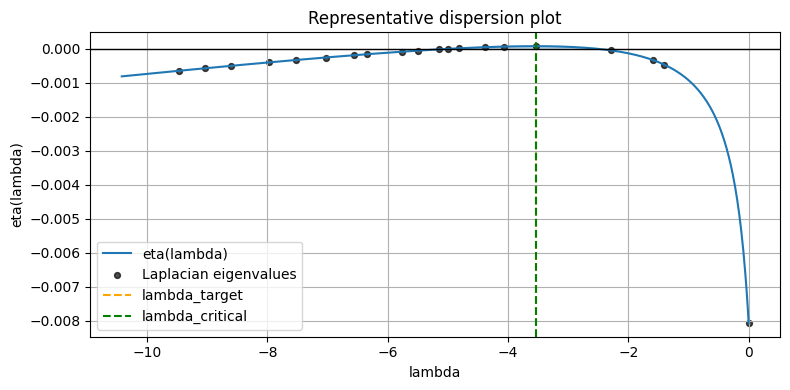

In [197]:
# 1) Representative dispersion plot
eigvals = lin_rep['eigenvalues']
eta_vals = np.array([eta_from_matrix(l, lin_rep['params_selected']) for l in eigvals])
lam_grid = np.linspace(min(-8.0, 1.1 * float(np.min(eigvals))), 0.0, 600)
eta_grid = np.array([eta_from_matrix(l, lin_rep['params_selected']) for l in lam_grid])

plt.figure(figsize=(8, 4))
plt.plot(lam_grid, eta_grid, color='C0', label='eta(lambda)')
plt.fill_between(lam_grid, 0, eta_grid, where=eta_grid > 0, alpha=0.2, color='C0')
plt.scatter(eigvals, eta_vals, s=18, color='black', alpha=0.7, label='Laplacian eigenvalues')

plt.axvline(lin_rep['lambda_target'], color='orange', linestyle='--', label='lambda_target')
plt.axvline(lin_rep['critical_eigenvalue'], color='green', linestyle='--', label='lambda_critical')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('lambda')
plt.ylabel('eta(lambda)')
plt.title('Representative dispersion plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

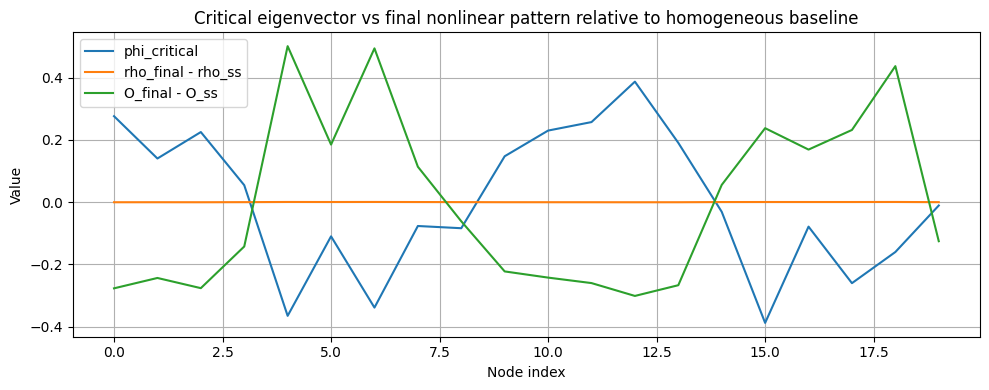

In [198]:
# 2) Critical eigenvector vs final centered patterns
phi = lin_rep['critical_eigenvector']
plt.figure(figsize=(10, 4))
plt.plot(phi, label='phi_critical')
plt.plot(z_rho_rep, label='rho_final - rho_ss')
plt.plot(z_O_rep, label='O_final - O_ss')
plt.title('Critical eigenvector vs final nonlinear pattern relative to homogeneous baseline')
plt.xlabel('Node index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

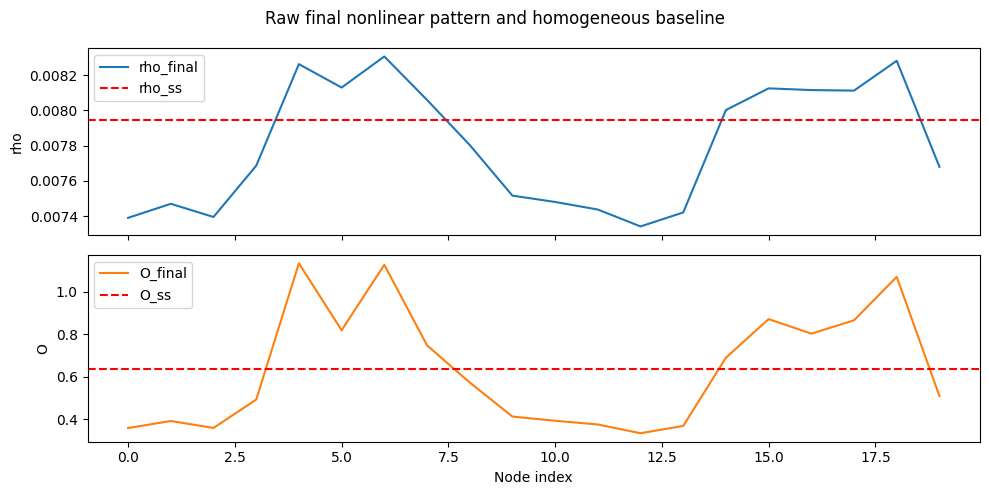

In [199]:
# 3) Raw final nonlinear pattern with homogeneous baselines
rho_ss_sel = lin_rep['params_selected']['rho_ss']
O_ss_sel = lin_rep['params_selected']['O_ss']

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(rho_final_rep, label='rho_final')
axes[0].axhline(rho_ss_sel, color='red', linestyle='--', label='rho_ss')
axes[0].set_ylabel('rho')
axes[0].legend()

axes[1].plot(O_final_rep, label='O_final', color='C1')
axes[1].axhline(O_ss_sel, color='red', linestyle='--', label='O_ss')
axes[1].set_ylabel('O')
axes[1].set_xlabel('Node index')
axes[1].legend()

fig.suptitle('Raw final nonlinear pattern and homogeneous baseline')
plt.tight_layout()
plt.show()

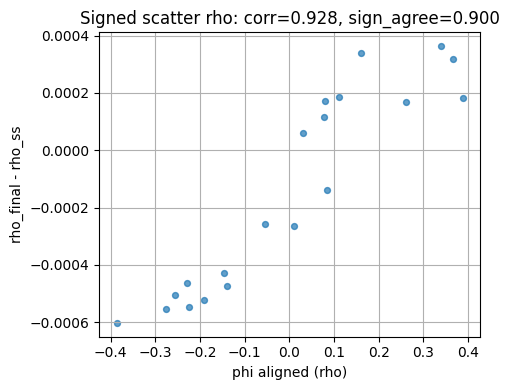

In [200]:
# 4) Signed scatter plot for rho
x = comp_rep['phi_rho_aligned']
y = comp_rep['z_rho']
plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=18, alpha=0.7)
plt.xlabel('phi aligned (rho)')
plt.ylabel('rho_final - rho_ss')
plt.title('Signed scatter rho: corr={:.3f}, sign_agree={:.3f}'.format(comp_rep['corr_signed_rho'], comp_rep['sign_agreement_rho']))
plt.grid(True)
plt.tight_layout()
plt.show()

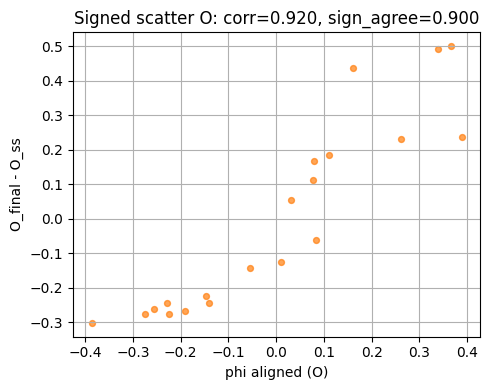

In [201]:
# 5) Signed scatter plot for O
x = comp_rep['phi_O_aligned']
y = comp_rep['z_O']
plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=18, alpha=0.7, color='C1')
plt.xlabel('phi aligned (O)')
plt.ylabel('O_final - O_ss')
plt.title('Signed scatter O: corr={:.3f}, sign_agree={:.3f}'.format(comp_rep['corr_signed_O'], comp_rep['sign_agreement_O']))
plt.grid(True)
plt.tight_layout()
plt.show()

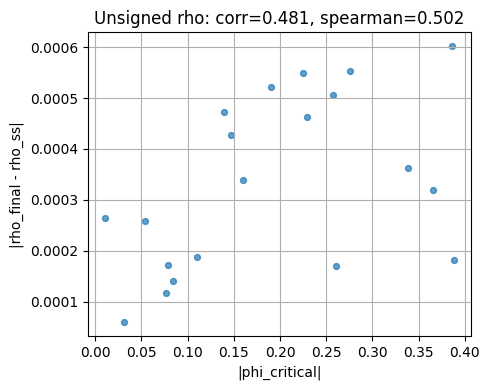

In [202]:
# 6) Unsigned magnitude scatter plot for rho
phi = lin_rep['critical_eigenvector']
x = np.abs(phi)
y = np.abs(z_rho_rep)
plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=18, alpha=0.7)
plt.xlabel('|phi_critical|')
plt.ylabel('|rho_final - rho_ss|')
plt.title('Unsigned rho: corr={:.3f}, spearman={:.3f}'.format(comp_rep['corr_abs_rho'], comp_rep['spearman_abs_rho']))
plt.grid(True)
plt.tight_layout()
plt.show()

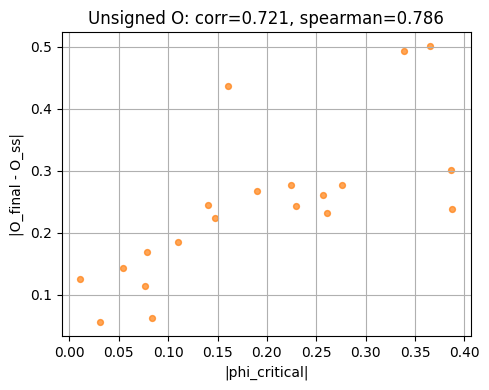

In [203]:
# 7) Unsigned magnitude scatter plot for O
phi = lin_rep['critical_eigenvector']
x = np.abs(phi)
y = np.abs(z_O_rep)
plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=18, alpha=0.7, color='C1')
plt.xlabel('|phi_critical|')
plt.ylabel('|O_final - O_ss|')
plt.title('Unsigned O: corr={:.3f}, spearman={:.3f}'.format(comp_rep['corr_abs_O'], comp_rep['spearman_abs_O']))
plt.grid(True)
plt.tight_layout()
plt.show()

## Ensemble results

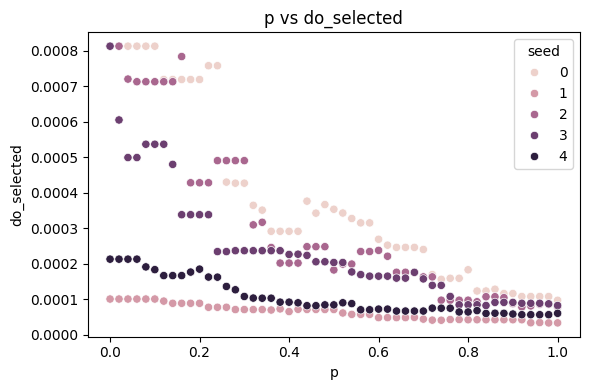

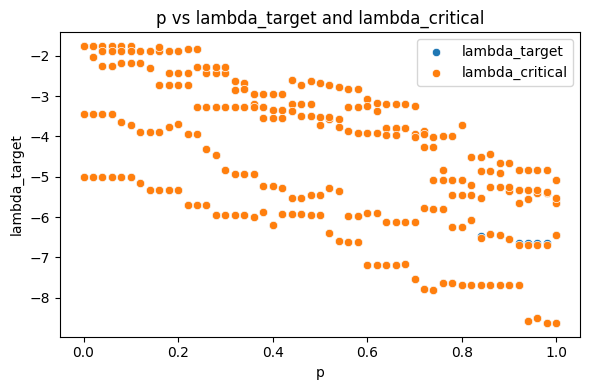

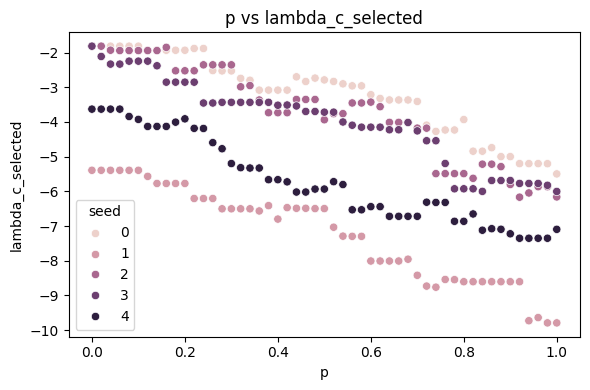

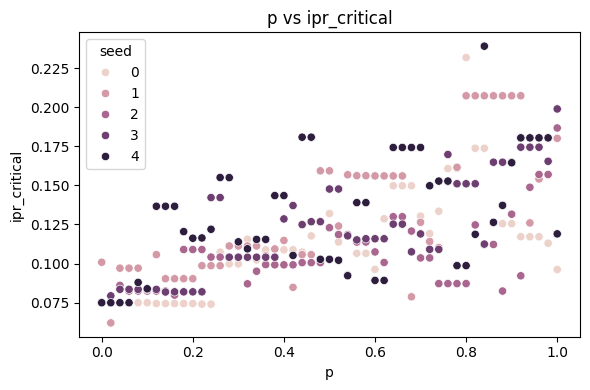

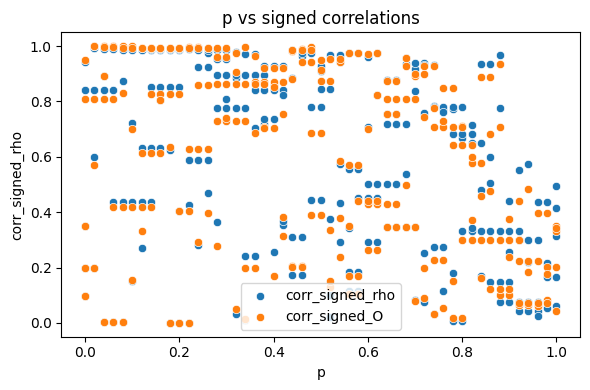

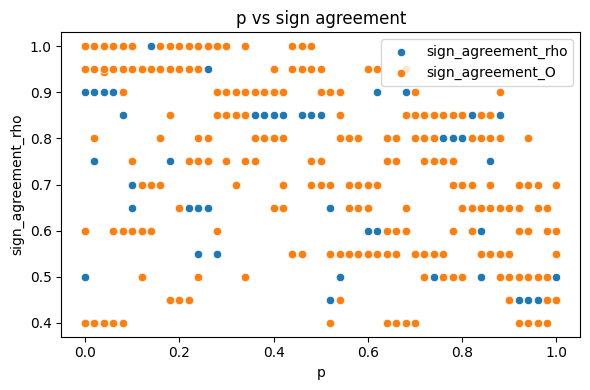

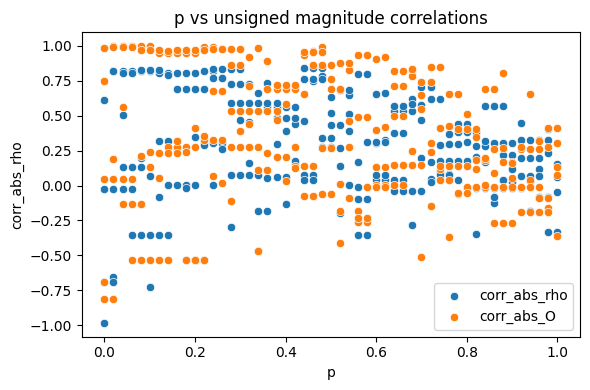

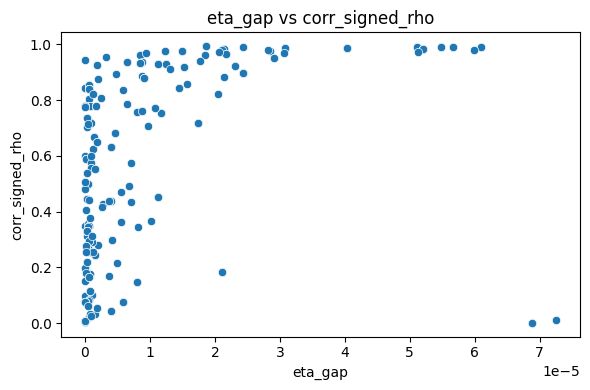

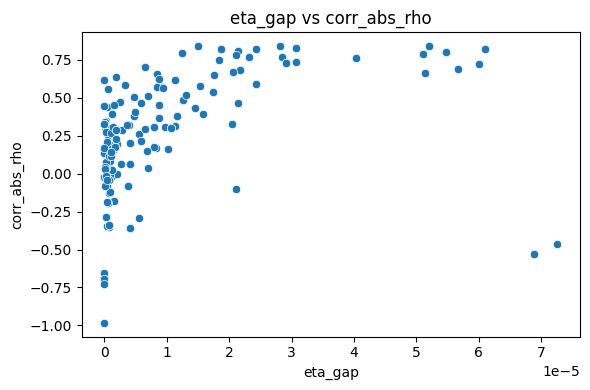

In [204]:
# 8–16) Ensemble summary plots
df = validation_df.copy()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='do_selected', hue='seed')
plt.title('p vs do_selected')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='lambda_target', label='lambda_target')
sns.scatterplot(data=df, x='p', y='lambda_critical', label='lambda_critical')
plt.title('p vs lambda_target and lambda_critical')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='lambda_c_selected', hue='seed')
plt.title('p vs lambda_c_selected')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='ipr_critical', hue='seed')
plt.title('p vs ipr_critical')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='corr_signed_rho', label='corr_signed_rho')
sns.scatterplot(data=df, x='p', y='corr_signed_O', label='corr_signed_O')
plt.title('p vs signed correlations')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='sign_agreement_rho', label='sign_agreement_rho')
sns.scatterplot(data=df, x='p', y='sign_agreement_O', label='sign_agreement_O')
plt.title('p vs sign agreement')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='p', y='corr_abs_rho', label='corr_abs_rho')
sns.scatterplot(data=df, x='p', y='corr_abs_O', label='corr_abs_O')
plt.title('p vs unsigned magnitude correlations')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='eta_gap', y='corr_signed_rho')
plt.title('eta_gap vs corr_signed_rho')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='eta_gap', y='corr_abs_rho')
plt.title('eta_gap vs corr_abs_rho')
plt.tight_layout()
plt.show()

In [205]:
# Sanity checks for acceptance criteria
import os

required_cols = [
    'topology','p','seed','n_nodes','n_neighbors','target_rule',
    'lambda_target','target_index','ipr_target','do_selected','Ic_selected','I_selected',
    'rho_ss_selected','O_ss_selected','lambda_c_selected',
    'lambda_critical','eta_max','eta_gap','number_unstable_modes','critical_index','ipr_critical',
    'stable_flag','integration_success',
    'rho_final_mean','rho_final_std','rho_final_min','rho_final_max',
    'O_final_mean','O_final_std','O_final_min','O_final_max',
    'corr_signed_rho','corr_signed_O','cosine_signed_rho','cosine_signed_O',
    'sign_agreement_rho','sign_agreement_O',
    'jaccard_above_rho','jaccard_above_O','jaccard_below_rho','jaccard_below_O',
    'corr_abs_rho','corr_abs_O','spearman_abs_rho','spearman_abs_O',
    'top5_overlap_abs_rho','top5_overlap_abs_O',
    'corr_squared_rho','corr_squared_O',
]

missing = [c for c in required_cols if c not in validation_df.columns]
print('Missing columns:', missing)
assert len(missing) == 0

csv_path = 'critical_eigenvector_final_pattern_validation_results.csv'
print('CSV exists:', os.path.exists(csv_path), '->', csv_path)

# At least one unstable graph integrated successfully
unstable_integrated = validation_df[(validation_df['stable_flag'] == False) & (validation_df['integration_success'] == True)]
print('Unstable + integrated rows:', len(unstable_integrated))
assert len(unstable_integrated) >= 1

Missing columns: []
CSV exists: True -> critical_eigenvector_final_pattern_validation_results.csv
Unstable + integrated rows: 255
